In [1]:
%reset -f 

from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [2]:
from ShakerMakerResults import ShakerMakerData

import numpy as np
import os

import h5py
import matplotlib.pyplot as plt


  ShakerMakerResults -- Visualization and Analysis Toolkit
  Built on top of Shakermaker Tool

  Version 1.0.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/ShakerMakerResults
  ShakerMaker :  https://github.com/ppalacios92/ShakerMaker

  Patricio Palacios B.    |    Ladruno Team
  
  ********* (>'-')> Ladruno4ever  *********



## Surface STG

In [3]:

# folder = r'C:\Users\ppala\Desktop\STG_Surface'
folder= '/home/pxpalacios/Desktop/STG_Surface'

h5drm = os.path.join(folder, 'STG_Surface.h5drm')
h5gf  = os.path.join(folder, 'STG_Surface_gf.h5')
h5map  = os.path.join(folder, 'STG_Surface_map.h5')


STG_surface = ShakerMakerData(h5drm)
STG_surface.load_gf_database(h5gf)
STG_surface.load_map(h5map)


  vmax cache loaded from sidecar.
----------------------------------------------------------------------------------------------------
ShakerMakerData  :  /home/pxpalacios/Desktop/STG_Surface/STG_Surface.h5drm
  Type     : DRM
  Model    : 500.0m  |  Spacing: 500.0m x 500.0m x 500.0m
  Domain   : Lx=31000.0m  Ly=31000.0m  Lz=500.0m
  Nodes    : 7938  |  Internal: 3721  |  External: 4217
  QA       : yes  ->  [6293815.47973042  349518.53893047       0.        ] m
  Time     : dt=0.005s  |  steps=20000  |  t=[0.000, 100.000]s
  GF       : steps=0  |  not loaded
  Version  : ShakerMaker version 1.1  |  13-Apr-2026 (01:28:15.273655)
  RAM      : 11.9 GB used  |  20.9 GB free  |  36.2%
  File size:
    acceleration         (23814, 20000)  3.81 GB
    displacement         (23814, 20000)  3.81 GB
    velocity             (23814, 20000)  3.81 GB
    xyz                  (7938, 3)  0.00 GB
    TOTAL                             11.43 GB
-----------------------------------------------------------

----------------------------------------------------------------------------------------------------
Resample
  Data dt  : 0.005000s -> 0.010000s
  Data     : 20000 -> 10000 samples
  Time     : [0.000, 99.995] s unchanged
  GF       : 16384 -> 8192 samples
  GF Time  : [0.000, 81.915] s unchanged
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
--------------------------------------------------


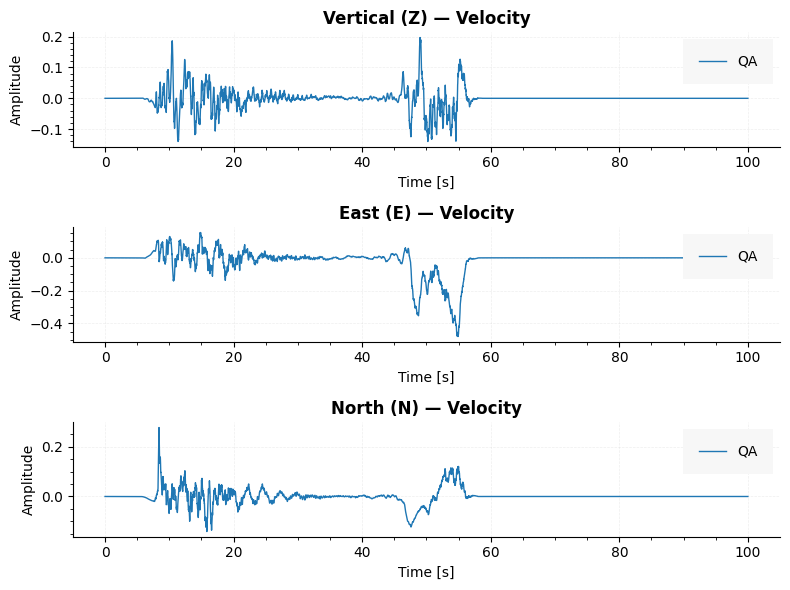

In [4]:
# resample 
STG_surface_resample = STG_surface.resample(dt=0.01)
STG_surface_resample.plot_node_response(
                                node_id='QA', 
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

----------------------------------------------------------------------------------------------------
Window   : I2_s5
  Range  : [0.000, 40.000] s
  Data   : 20000 -> 8001 samples
  Time   : [0.000, 99.995] -> [0.000, 40.000] s
  GF     : 16384 -> 8001 samples
----------------------------------------------------------------------------------------------------

--------------------------------------------------
NODE INFO
  N3971   │ pos = [6309315.48,  365018.54,       0.00] m │ external
  Target   │ pos = [6293815480.00, 349518540.00,       0.00] m │ dist = 6297193180.33 m
--------------------------------------------------


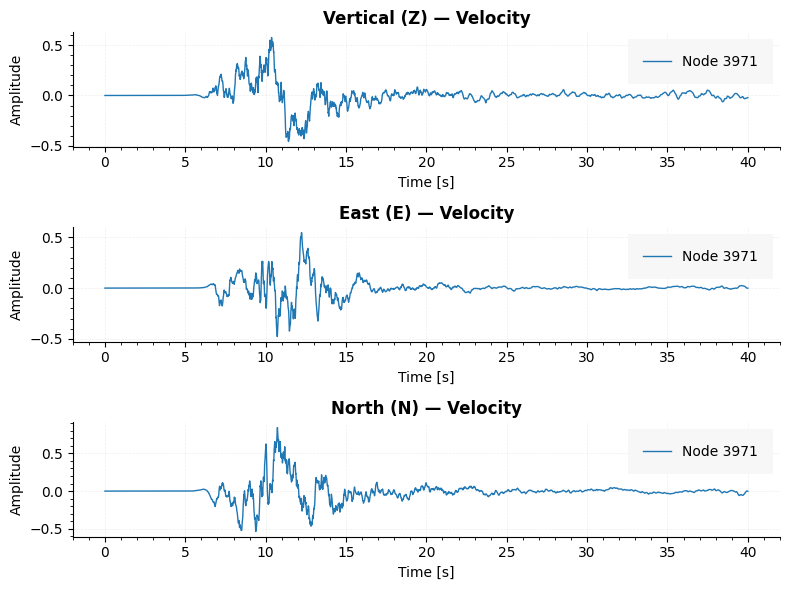

In [5]:
# get_window

STG_surface_window= STG_surface.get_window(t_start=0.0, t_end=40.0)

STG_surface_window.plot_node_response(
                                target_pos=[6293815.48,  349518.54,       0.00],
                                data_type='vel', 
                                figsize=(8, 6),
                                factor=1.0,
                                )

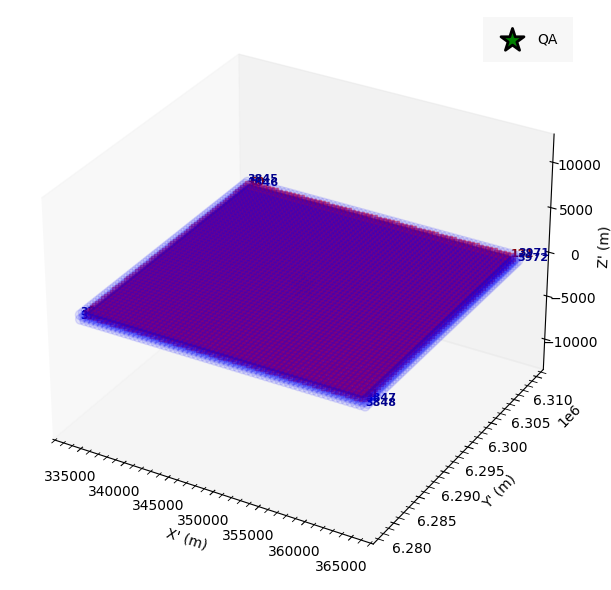

QA position: [ 349518.53893047 6293815.47973042       0.        ]


(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [6]:
STG_surface_window.plot_domain( 
    xyz_origin=None,
    label_nodes='corners',
    show_calculated=False,
    figsize=(8, 6),
    axis_equal=True,
)

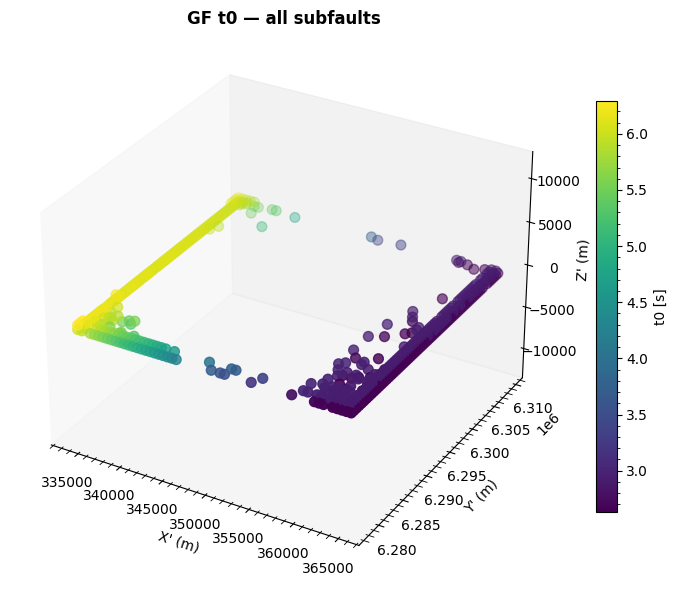

Calculated: 456  |  t0 range: 2.636 .. 6.294 s


(<Figure size 800x600 with 2 Axes>,
 <Axes3D: title={'center': 'GF t0 — all subfaults'}, xlabel="X' (m)", ylabel="Y' (m)", zlabel="Z' (m)">)

In [7]:
STG_surface_window.plot_domain_calculated_t0(
    subfault='all',
    xyz_origin=None,
    show_calculated_only=True,
    figsize=(8, 6),
    axis_equal=True,
    cmap="viridis",
)

----------------------------------------------------------------------------------------------------
GF NODE CLASSIFICATION
  Super Donors    (91)  :  [0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 13, 15, 18, 19, 20, 23, 25, 27, 30, 32, 34, 37, 39, 41, 44, 46, 48, 51, 53, 54, 56, 58, 59, 60, 61, 62, 63, 64, 68, 140, 179, 3722, 3724, 3726, 3728, 3732, 3734, 3736, 3738, 3740, 3746, 3748, 3750, 3754, 3756, 3758, 3760, 3764, 3766, 3770, 3774, 3778, 3784, 3788, 3792, 3798, 3802, 3806, 3812, 3816, 3820, 3822, 3826, 3830, 3836, 3838, 3840, 3842, 3843, 3844, 3846, 3848, 3850, 3852, 3856, 4088, 4090, 4092, 4102, 4217, 4588]
  Solitary Donors (365)  :  [9, 12, 17, 22, 24, 28, 29, 31, 33, 35, 36, 38, 40, 42, 43, 45, 47, 49, 50, 52, 55, 57, 65, 66, 67, 69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 116, 117, 119, 120, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 13

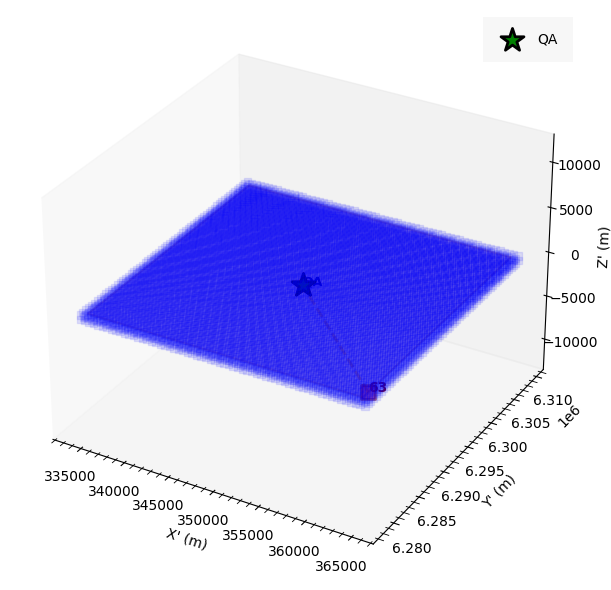

In [8]:
STG_surface_window.plot_gf_connections(
                        node_id='QA',
                        xyz_origin=None,
                        label_nodes='donor_receivers',
                        figsize=(8,6),
                        axis_equal=True)  

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
  N0      │ pos = [6278815.48,  334518.54,       0.00] m │ internal
  N1000   │ pos = [6285315.48,  361018.54,       0.00] m │ internal
--------------------------------------------------


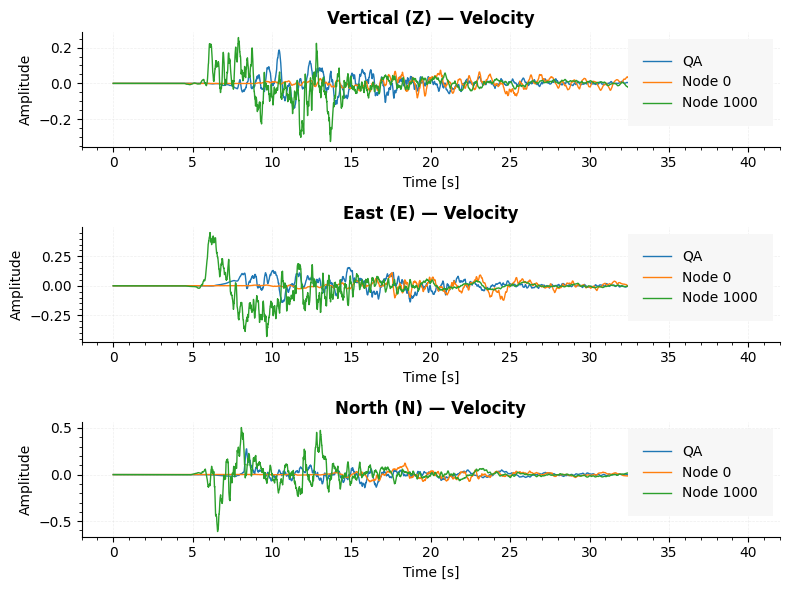

In [9]:
# Por ID
STG_surface_window.plot_node_response( 
                        node_id=['QA' , 0,1000], 
                        data_type='vel', 
                        figsize=(8, 6),
                        factor=1.0,
                        )

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
  N0      │ pos = [6278815.48,  334518.54,       0.00] m │ internal
  N1000   │ pos = [6285315.48,  361018.54,       0.00] m │ internal
--------------------------------------------------


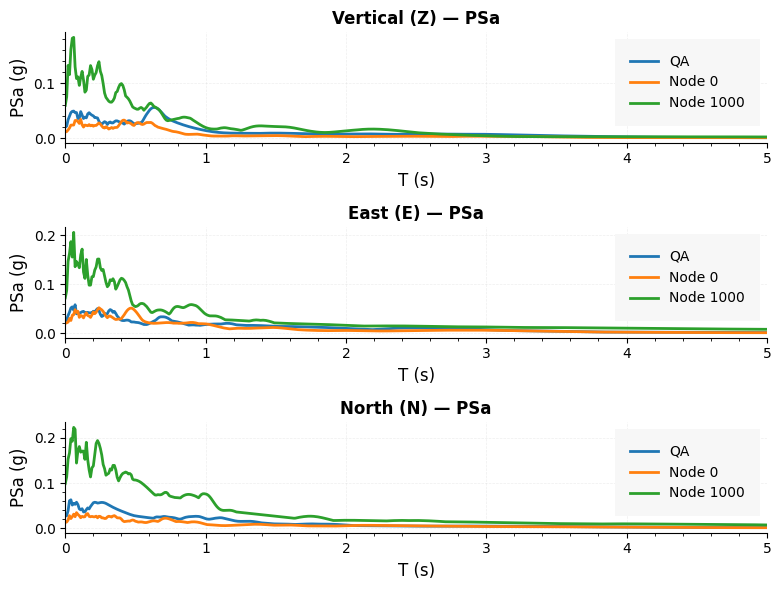

In [10]:
# Por ID
STG_surface_window.plot_node_newmark( 
                        node_id=['QA' , 0,1000], 
                        data_type='accel', 
                        spectral_type='PSa',
                        figsize=(8, 6),
                        factor=1/9.81,
                        )

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
--------------------------------------------------
Node QA/sub 0 → slot 23142 (donor 63)


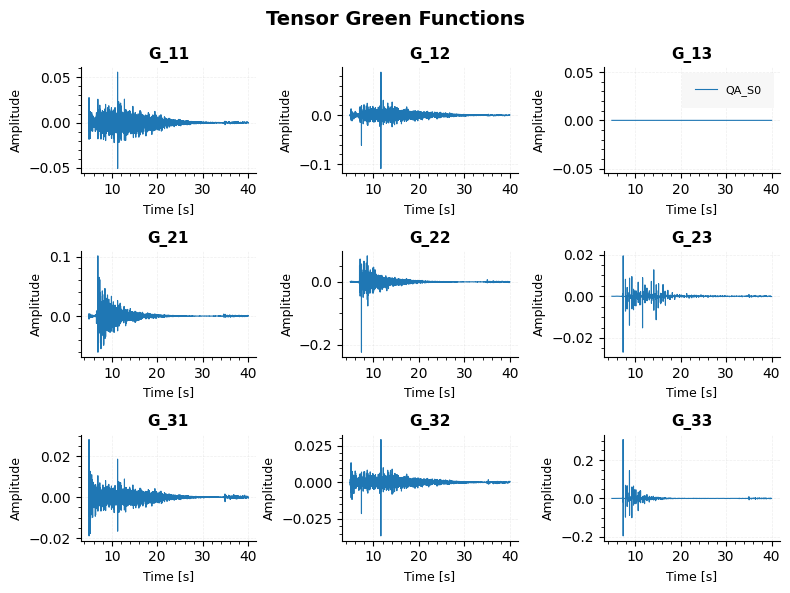

{'QA_S0': {'tdata': array([[ 1.27557432e-04, -7.49146493e-05,  0.00000000e+00, ...,
           8.57774830e-06, -1.14746690e-04, -3.37462858e-08],
         [ 1.88167294e-04, -1.20199395e-04,  0.00000000e+00, ...,
           7.66044323e-05, -1.48857696e-04,  1.93404176e-05],
         [ 1.02992220e-04, -5.81338500e-05,  0.00000000e+00, ...,
           4.19309936e-06, -7.48131570e-05,  3.79919511e-05],
         ...,
         [-4.50218562e-04,  8.88022769e-04,  0.00000000e+00, ...,
          -5.14365907e-04,  6.14704215e-04,  3.60179140e-04],
         [-4.60733921e-04,  8.22882517e-04,  0.00000000e+00, ...,
          -5.43894828e-04,  5.73335739e-04,  3.66791326e-04],
         [-3.35237855e-04,  7.35572772e-04,  0.00000000e+00, ...,
          -4.18490643e-04,  4.67493897e-04,  3.88704968e-04]],
        shape=(7023, 9)),
  'time': array([ 4.88882065,  4.89382065,  4.89882065, ..., 39.98882065,
         39.99382065, 39.99882065], shape=(7023,)),
  't0': 4.888820648193359,
  'node_id': 7938}}

In [11]:
STG_surface_window.plot_node_tensor_gf(
                        node_id=['QA'],
                        subfault=0, 
                        figsize=(8, 6),
                        )

--------------------------------------------------
NODE INFO
  QA       │ pos = [6293815.48,  349518.54,       0.00] m
  N0      │ pos = [6278815.48,  334518.54,       0.00] m │ internal
  N1000   │ pos = [6285315.48,  361018.54,       0.00] m │ internal
--------------------------------------------------


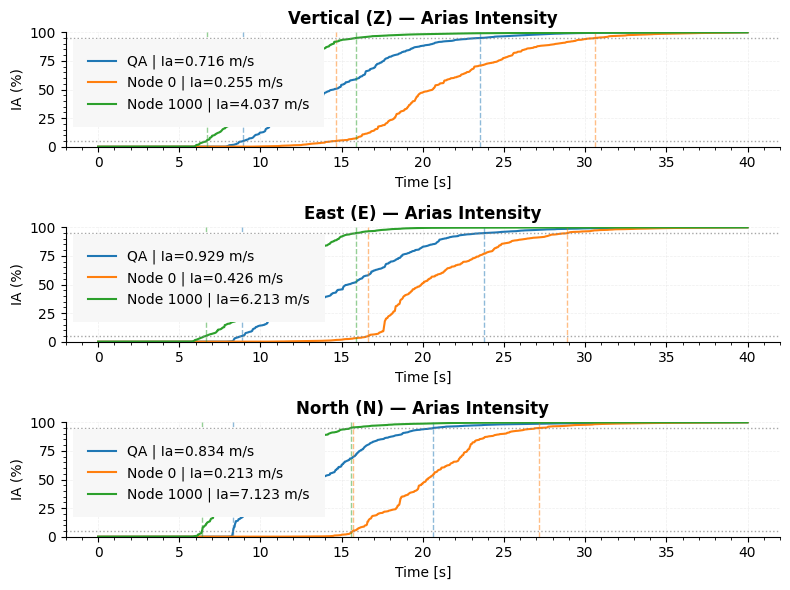

In [12]:
STG_surface_window.plot_node_arias(              
                    node_id=['QA' , 0,1000],
                    data_type     = 'accel',
                    figsize=(8, 6),
                    factor=1,
                    )

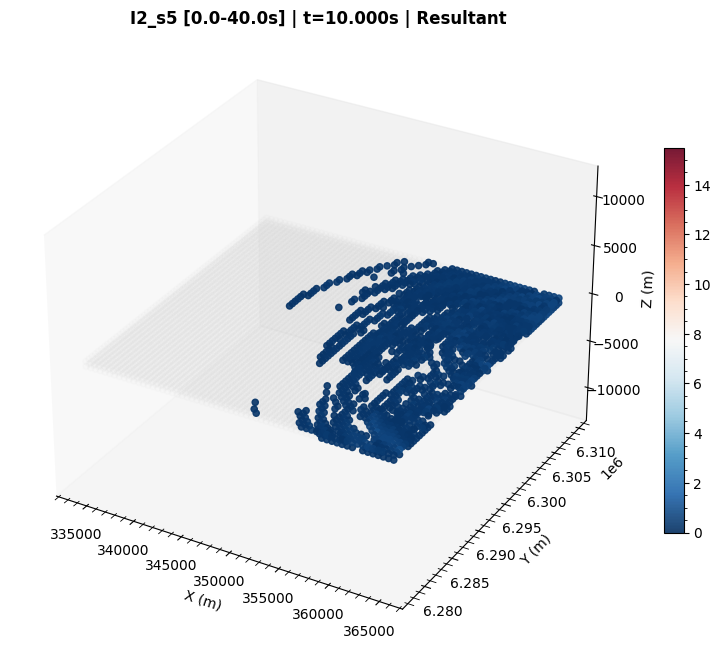

In [13]:
# Plot surface snapshot
STG_surface_window.plot_surface(  time=10.0, 
                            component='resultant', 
                            data_type='vel', 
                            cmap='RdBu_r', 
                            figsize=(8, 8),
                            elev=30, azim=-60, s=20, alpha=0.9,
                            axis_equal=True,)
    

Computing spectra for 7938 nodes  n_jobs=-2
  Mode     : safe/chunk  (3.8 GB needed  |  19.3 GB available)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 23 concurrent workers.



  ShakerMakerResults -- Visualization and Analysis Toolkit
  Built on top of Shakermaker Tool

  Version 1.0.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/ShakerMakerResults
  ShakerMaker :  https://github.com/ppalacios92/ShakerMaker

  Patricio Palacios B.    |    Ladruno Team
  
  ********* (>'-')> Ladruno4ever  *********


  ShakerMakerResults -- Visualization and Analysis Toolkit
  Built on top of Shakermaker Tool

  Version 1.0.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/ShakerMakerResults
  ShakerMaker :  https://github.com/ppalacios92/ShakerMaker

  Patricio Palacios B.    |    Ladruno Team
  
  ********* (>'-')> Ladruno4ever  *********


  ShakerMakerResults -- Visualization and Analysis Toolkit
  Built on top of Shakermaker Tool

  Version 1.0.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/ShakerMakerResult

[Parallel(n_jobs=-2)]: Done  26 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-2)]: Done 116 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-2)]: Done 242 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-2)]: Done 404 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-2)]: Done 602 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-2)]: Done 836 tasks      | elapsed:   12.5s
[Parallel(n_jobs=-2)]: Done 1106 tasks      | elapsed:   15.7s
[Parallel(n_jobs=-2)]: Done 1412 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-2)]: Done 1754 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-2)]: Done 2132 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-2)]: Done 2546 tasks      | elapsed:   33.2s
[Parallel(n_jobs=-2)]: Done 2996 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-2)]: Done 3482 tasks      | elapsed:   44.5s
[Parallel(n_jobs=-2)]: Done 4004 tasks      | elapsed:   50.8s
[Parallel(n_jobs=-2)]: Done 4562 tasks      | elapsed:   57.5s
[Parallel(n_jobs=-2)]: Done 5156 tasks      | elapsed:  1.1mi

Done. All spectral quantities cached for accel
  PSa(T=0.0s) | resultant | Max=1.3717  Min=0.0641


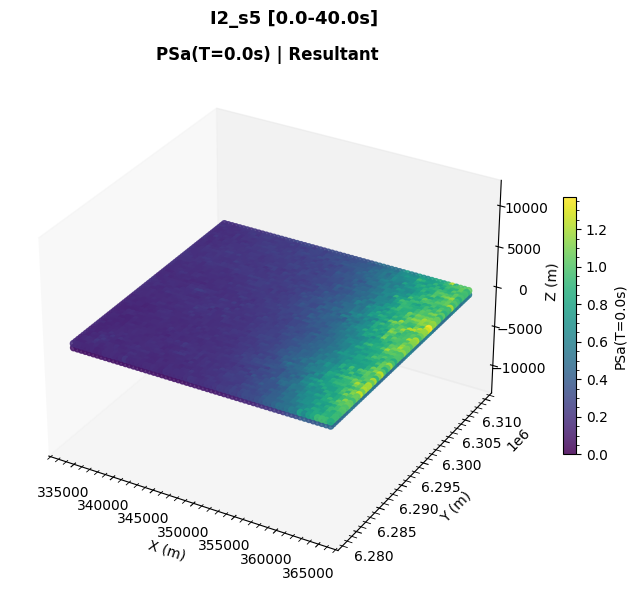

In [14]:
STG_surface_window.plot_surface_newmark(
                        T_target      = 0.0,
                        component     = 'resultant',
                        data_type     = 'accel',
                        spectral_type = 'PSa',
                        factor        = 1.0/9.81,
                        cmap          = 'viridis',
                        figsize       = (8, 6),
                        # elev          = 35,
                        # azim          = -60,
                        s             = 20,
                        alpha         = 0.85,
                        axis_equal    = True,
                        n_jobs        = -2,
)

Computing Arias intensity for 7938 nodes  n_jobs=-2
  Mode     : safe/chunk  (3.8 GB needed  |  15.8 GB available)


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 23 concurrent workers.
[Parallel(n_jobs=-2)]: Done  26 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-2)]: Done 117 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-2)]: Done 671 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-2)]: Done 5511 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-2)]: Done 7938 out of 7938 | elapsed:    1.6s finished


Done. Arias intensity cached for accel
  Arias | z | factor=1.0  Max=9.9404  Min=0.0466


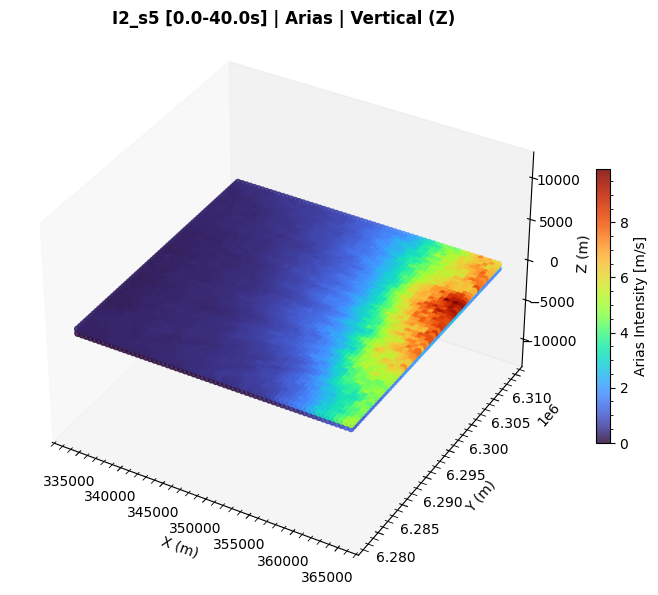

In [15]:
STG_surface_window.plot_surface_arias(
                    component  = 'z',
                    data_type  = 'accel',
                    factor     = 1.0,
                    cmap       = 'turbo',
                    figsize       = (8, 6),
                    elev          = 35,
                    azim          = -60,
                    s          = 20,
                    alpha      = 0.85,
                    axis_equal = True,
                    n_jobs     = -2,
)

In [16]:
STG_surface_window.viewer()